# Simulating different machine types

The other examples all track a conventional **RF linac** (a photoinjector followed by accelerating
cavities). `SIMBA` is a *start-to-end, single-pass* framework, but within that scope it can model
quite different kinds of machine, because each section just names the code best suited to its physics.
This notebook shows two regimes that look nothing like the JFEL linac:

1. a **plasma-accelerator stage** tracked with **Wake-T**, and
2. a **space-charge-dominated photoinjector** tracked with **GPT** (contrasted with ASTRA).

Both follow the same pattern you have already seen — a `files:` section with a `code:` — so the point
here is *what changes* for a different machine, not new API.

> **Scope note.** `SIMBA` orchestrates single-pass beamlines. Genuinely *circular* machines
> (storage rings, closed-orbit / multi-turn tracking, dynamic aperture) are outside that scope — for
> those, drive the underlying code (e.g. Elegant or MAD-X) in its ring mode directly. Everything below
> is single-pass.

## Part 1 — A plasma-accelerator stage with Wake-T

[Wake-T](https://github.com/AngelFP/Wake-T) models beam- and laser-driven **plasma wakefield**
acceleration: instead of RF cavities, the beam rides the wake in a plasma stage and can gain GeV-scale
energy over centimetres. In `SIMBA` a plasma stage is just another section, `code: waket`, that takes
an incoming distribution and tracks it through the plasma. A couple of things are specific to this
regime:

* the section is usually **driven by an external beam file** (`input: particle_definition:`), not a
  cathode generator — you hand it a beam produced upstream (e.g. by an RF injector, or a synthetic
  Gaussian);
* Wake-T is pure python, so like Ocelot/Cheetah it needs **no `SimCodes` directory**;
* drifts may legitimately be **negative** around plasma injection, which Wake-T allows.

A minimal `.def` for a stand-alone plasma stage looks like this:

```yaml
files:
  plasma_stage:
    code: waket
    input:
      particle_definition: driver_beam    # an existing <name>.openpmd.hdf5 beam file
    output:
      start_element: PLASMA-STAGE-START
      end_element:   PLASMA-STAGE-END
layout:  /path/to/your-lattice/layouts.yaml
section: /path/to/your-lattice/sections.yaml
element_list: /path/to/your-lattice/YAML/summary.yaml
```

> **TODO before running:** you need a LAURA lattice that contains plasma-stage elements (the
> `PLASMA-STAGE-*` names above are placeholders) and an input beam file `driver_beam.openpmd.hdf5`.
> The framework calls below are identical regardless — only the lattice and beam change.

First, make an input beam to inject. We reuse the `frameworkGenerator` (as in the
[Getting started](https://simba-accelerator.readthedocs.io/en/latest/getting-started.html) docs) to
synthesise a compact, high-energy bunch to drive/witness in the plasma — no cathode needed.

In [1]:
import os
from simba.Codes.Generators import frameworkGenerator
import simba.Modules.Beams as rbf

outdir = "./plasma_run"
os.makedirs(outdir, exist_ok=True)

gen = frameworkGenerator(
    global_parameters={"master_subdir": outdir},
    filename="plasma.openpmd.hdf5",
    initial_momentum=100e6,   # ~100 MeV witness bunch
    sigma_x=3e-6, sigma_px=1e3,
    sigma_y=3e-6, sigma_py=1e3,
    sigma_z=3e-6, sigma_pz=1e0,
    charge=10e-12,
    number_of_particles=10000,
)
gen.write()
beam = rbf.beam(filename=f"{outdir}/plasma.openpmd.hdf5")

Then set up and track the plasma section. This is the same `Framework` → `loadSettings` → `track`
flow as every other example; the only difference is that the section's code is `waket` and it starts
from a beam file rather than a generator.

In [1377]:
from laura.models.elementList import ElementList, SectionLattice, MachineLayout
from laura.models.element import Plasma, Screen
from laura import LAURA
from laura.Exporters.YAML import export_machine

plasma = Plasma(
    name="plasma",
    machine_area="plasma_line",
    physical={
        "middle": {"x": 0.0, "y": 0.0, "z": 0.005},
        "length": 0.01,
    },
    plasma={
        "density": 1e23,
        "ramp_up": 0.001,
        "ramp_down": 0.001,
        "plateau": 0.01,
        "ramp_decay_length": 0.0002,
        "density_profile": True
    },
    simulation={
        "wakefield_model": "quasistatic_2d",
        "r_max": 60e-6,
        "n_radial": 100,
        "n_longitudinal": 100,
        "min_longitudinal_position": -0.5e-3,
        "max_longitudinal_position": 0.5e-3,
    },
    laser={
        "focal_position": 8e-3,
        "waist": 50e-6,
        "wavelength": 800e-9,
        "pulse_energy": 3,
        "pulse_duration_fwhm": 60e-15,
        "initial_position": 50e-6,
    }
)

screen = Screen(
    name="screen",
    machine_area="plasma_line",
    position={"x": 0.0, "y": 0.0, "z": 0.01},
)

element_list = ElementList(
    elements={
        "plasma": plasma,
        "screen": screen,
    }
)

section = SectionLattice(
    name="plasma_line",
    order=["plasma", "screen"],
    elements=element_list,
)

layout = MachineLayout(
    name="beamline",
    sections={"plasma_line": section}
)

sections = {"sections": {section.name: section.names}}
layouts = {"default_layout": "beamline", "layouts": {"beamline": [section.name]}}
machine = LAURA(element_list=element_list.elements.values(), layout=layouts, section=sections)
export_machine(f"{outdir}/lattice", machine, overwrite=True)

In [2]:
import simba.Framework as fw

settings = fw.FrameworkSettings()
settings.files = {
    "plasma_line": {
        "code": "waket",
        "output": {
            "start_element": "plasma",
            "end_element": "screen",
        }
    }
}
settings.layout = machine.layout
settings.section = {"sections": {name: e.names for name, e in machine.sections.items()}}
settings.element_list = os.path.join(outdir, "lattice")

In [7]:
from simba.Framework import load_directory

framework = fw.Framework(
    directory=outdir,
    machine=machine,
    clean=False,
    verbose=False,
)
framework.loadSettings(settings=settings)
framework.global_parameters["beam"] = beam
framework.track(startfile="plasma_line", endfile="plasma_line")

In [1384]:
beam = rbf.beam(f"{outdir}/screen.openpmd.hdf5")

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: xlabel='t (fs)', ylabel='cpz (MeV/c)'>)

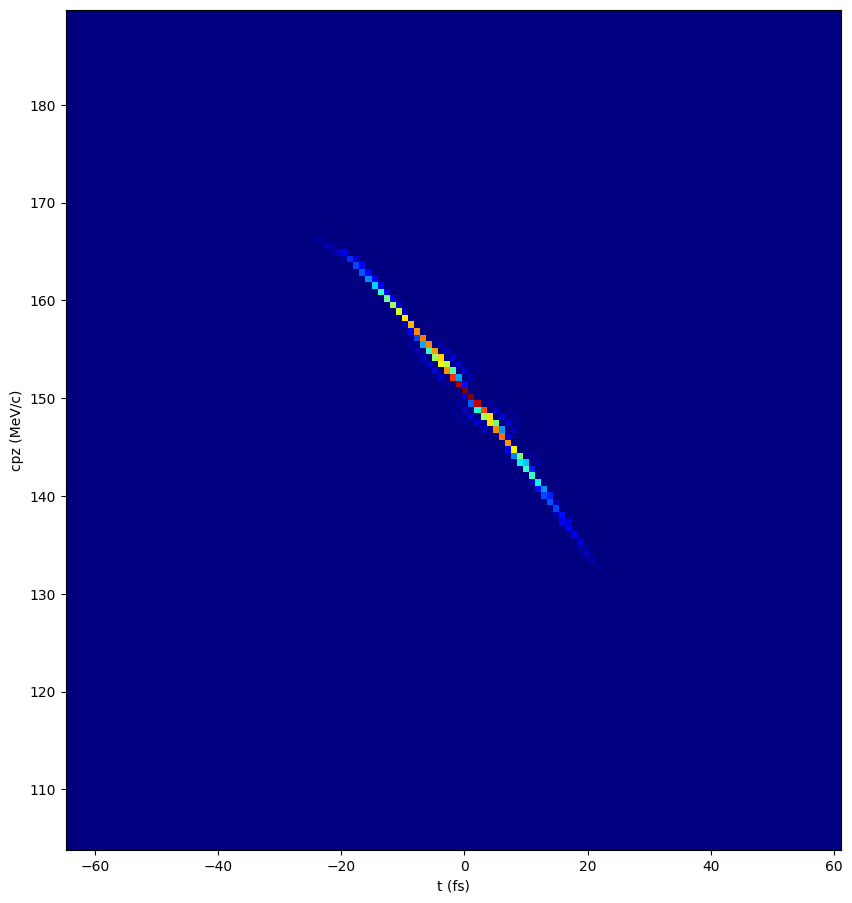

In [1385]:
from simba.Modules.Beams.plot import plotScreenImage

plotScreenImage(beam, ["t", "cpz"])

## Part 2 — A space-charge-dominated photoinjector (GPT vs ASTRA)

The other end of the spectrum from a plasma stage is the **low-energy photoinjector**, where the beam
leaves the cathode at a few MeV and its own **space charge** dominates the dynamics. `SIMBA` supports
two codes for this regime — **ASTRA** and **GPT** — and because the lattice is defined once, you can
run the *same* injector through either and compare.

The JFEL `injector400` section already runs in ASTRA. Switching it to GPT is a one-liner with
`change_generator` (for the cathode distribution) and `change_Lattice_Code` (for the tracking), the
same mechanism used in the [chaining example](start_to_end_chain.ipynb). Both codes need the
`SimCodes` directory.

In [3]:
import os

# Set your own environment variables here
os.environ["LATTICE_LOCATION"]="/path/to/lattice/"
os.environ["SIMCODES"]="/path/to/simcodes"

In [11]:
framework = fw.Framework(
    simcodes=os.environ.get("SIMCODES"),
    directory="./injector_compare/astra",
    master_lattice=os.environ.get("LATTICE_LOCATION"),   # laura-lattices/JFEL
    generator_defaults="jfel.yaml",
    clean=True,
    verbose=False,
)
framework.loadSettings("Lattices/jfel_combined.def")

In [12]:
# --- run the injector in ASTRA (as shipped) ---
framework.change_generator("ASTRA")
framework.generator.load_defaults("jfel_400_3ps")
framework.generator.number_of_particles = 2 ** (3 * 2)
framework.setSubDirectory("./injector_compare/astra")
framework.track(startfile="generator", endfile="injector400")
astra_dir = load_directory("./injector_compare/astra", beams=True)

In [8]:
# --- run the same injector in OPAL ---
framework.change_Lattice_Code("injector400", "opal")
framework.generator.number_of_particles = 2 ** (3 * 2)
framework.setSubDirectory("./injector_compare/opal")
framework.track(startfile="generator", endfile="injector400")
opal_dir = load_directory("./injector_compare/opal", beams=True)

(<Axes: xlabel='z (m)', ylabel='$\\sigma_x$, $\\sigma_y$ (mm)'>, None, None)

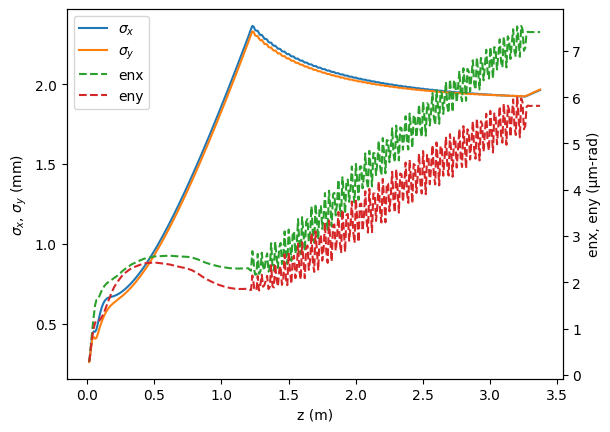

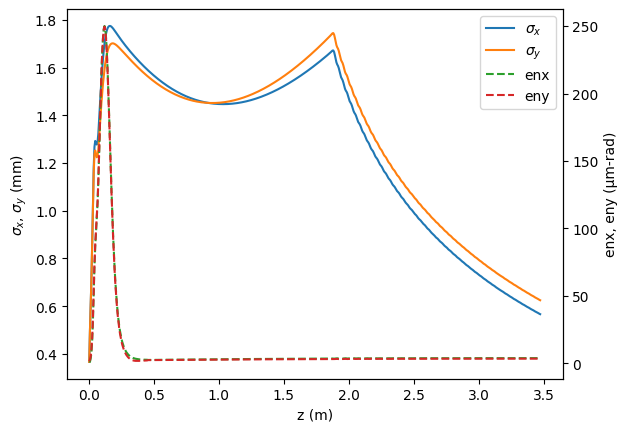

In [13]:
# Plot the emittance evolution through the injector for each code (same lattice, two space-charge
# algorithms). Compare the two figures side by side.
astra_dir.plot(xkey="z", ykeys=["sigma_x", "sigma_y"], ykeys2=["enx", "eny"])
opal_dir.plot(xkey="z", ykeys=["sigma_x", "sigma_y"], ykeys2=["enx", "eny"])

> The two space-charge algorithms will not agree to the last digit — that disagreement *is* the point.
> Running an injector through both codes is a standard way to bound the numerical uncertainty of a
> space-charge-dominated design before trusting it.

### Cleanup

In [ ]:
import shutil
for d in ("./plasma_run", "./injector_compare"):
    shutil.rmtree(d, ignore_errors=True)

### Recap

* `SIMBA` is single-pass S2E, but that still spans very different machines — swap the section's `code:`
  to match the physics.
* **Wake-T** (`code: waket`) models plasma-wakefield stages, usually driven by an injected beam file
  rather than a cathode; it is pure python (no SimCodes).
* **GPT** and **ASTRA** both model space-charge-dominated photoinjectors; running the same lattice
  through both is an easy cross-check.
* Rings / multi-turn tracking are out of scope — use the underlying code's ring mode directly.